## Problema de classificação

In [105]:
import torch
from torch import nn
import time

In [61]:
torch.manual_seed(42)

if torch.cuda.is_available():
  device  = torch.device("cuda")
else:
  device = torch.device("cpu")

print(device)

cpu


In [62]:
from sklearn import datasets

wine = datasets.load_wine()
data = wine.data
target = wine.target

print(data.shape, target.shape)
print(wine.feature_names, wine.target_names)

(178, 13) (178,)
['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline'] ['class_0' 'class_1' 'class_2']


In [63]:
class WineClassifier(nn.Module):
  def __init__(self, input_size, hidden_size, out_size):
    super(WineClassifier, self).__init__()

    self.hidden = nn.Linear(input_size,hidden_size)
    self.relu = nn.ReLU()
    self.output = nn.Linear(hidden_size, out_size)
    self.softmax = nn.Softmax()

  def forward(self, X):
    feature = self.relu(self.hidden(X))
    output = self.softmax(self.output(feature))

    return output

input_size = data.shape[1] # 13
hidden_size = 32
out_size = len(wine.target_names)

model = WineClassifier(input_size, hidden_size, out_size).to(device)

In [64]:
print(model)

WineClassifier(
  (hidden): Linear(in_features=13, out_features=32, bias=True)
  (relu): ReLU()
  (output): Linear(in_features=32, out_features=3, bias=True)
  (softmax): Softmax(dim=None)
)


In [65]:
criterion = nn.CrossEntropyLoss().to(device)

Xtensor = torch.from_numpy(data).float()
Ytensor = torch.from_numpy(target)

print(Xtensor.dtype, Ytensor.dtype)

torch.float32 torch.int64


In [66]:
Xtensor = torch.from_numpy(data).float()
print(Xtensor.dtype, Ytensor.dtype)

torch.float32 torch.int64


In [67]:
Xtensor = Xtensor.to(device)
Ytensor = Ytensor.to(device)

In [68]:
pred = model(Xtensor)
print(Xtensor.shape)
print(pred.shape)

torch.Size([178, 13])
torch.Size([178, 3])


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1739: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


Função de perda, ou seja, média entrediferença entre a predição e o y real

In [69]:
loss = criterion(pred, Ytensor)
print(loss)

tensor(1.1526, grad_fn=<NllLossBackward0>)


## Problema de regressão

In [70]:
from sklearn import datasets

diabetes = datasets.load_diabetes()
data = diabetes.data
target = diabetes.target

print(data.shape, target.shape)
print(data[0])
print(target[0])

(442, 10) (442,)
[ 0.03807591  0.05068012  0.06169621  0.02187239 -0.0442235  -0.03482076
 -0.04340085 -0.00259226  0.01990749 -0.01764613]
151.0


In [71]:
class DiabetesClassifier(nn.Module):
  def __init__(self, input_size, hidden_size, out_size):
    super(DiabetesClassifier, self).__init__()

    self.hidden = nn.Linear(input_size,hidden_size)
    self.relu = nn.ReLU()
    self.output = nn.Linear(hidden_size, out_size)
    self.softmax = nn.Softmax()

  def forward(self, X):
    feature = self.relu(self.hidden(X))
    output = self.softmax(self.output(feature))

    return output

input_size = data.shape[1] # 13
hidden_size = 32
out_size = 1 # progressão da diabetes

model = DiabetesClassifier(input_size, hidden_size, out_size).to(device)

In [72]:
criterion = nn.MSELoss().to(device)

Xtensor = torch.from_numpy(data).float().to(device)
Ytensor = torch.from_numpy(target).to(device)

print(Xtensor.shape, Ytensor.shape)

torch.Size([442, 10]) torch.Size([442])


In [73]:
pred = model(Xtensor)
print(pred.shape)

torch.Size([442, 1])


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1739: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


É preciso tirar uma dimensão da predição para poder calcular a perda (squeeze)

In [74]:
loss = criterion(pred.squeeze(), Ytensor)
print(loss.data)

tensor(28771.2149, dtype=torch.float64)


In [75]:
#passando um único valor
pred = model(Xtensor[0].unsqueeze(0))
loss = criterion(pred.squeeze(), Ytensor)
print(loss.data)

tensor(28771.2149, dtype=torch.float64)


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/loss.py:610: UserWarning: Using a target size (torch.Size([442])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


In [76]:
print(loss)

tensor(28771.2149, dtype=torch.float64, grad_fn=<MseLossBackward0>)


## Otimização

Text(0, 0.5, 'color_intensity')

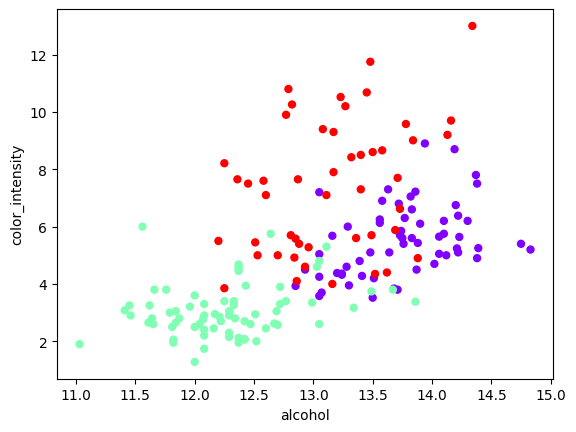

In [77]:
import matplotlib.pyplot as plt

features = [0,9]
data = wine.data[:, features]
targets = wine.target

plt.scatter(data[:,0], data[:,1], c=targets ,cmap='rainbow', s=25)
plt.xlabel(wine.feature_names[features[0]])
plt.ylabel(wine.feature_names[features[1]])

Os dados estão em intervalos diferentes. Por isso necessário normalizar

Text(0, 0.5, 'color_intensity')

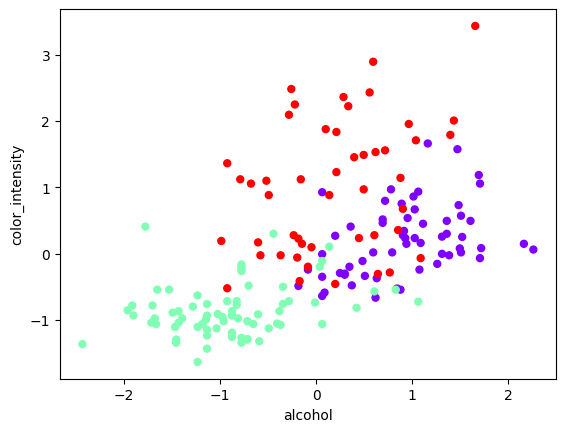

In [78]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
data = scaler.fit_transform(data)

plt.scatter(data[:,0], data[:,1], c=targets ,cmap='rainbow', s=25)
plt.xlabel(wine.feature_names[features[0]])
plt.ylabel(wine.feature_names[features[1]])

Função de fronteira de decisão adaptada de:
https://github.com/camilalaranjeira/Neural-Lectures/blob/master/XOR_Problem.ipynb

In [79]:
torch.manual_seed(42)

if torch.cuda.is_available():
  device = torch.device('cuda')
else:
  device = torch.device('cpu')

print(device)

input_size  = data.shape[1]
hidden_size = 32
out_size    = len(wine.target_names) # numero de classes

model = nn.Sequential(
    nn.Linear(input_size, hidden_size),
    nn.ReLU(),
    nn.Linear(hidden_size, out_size),
    nn.Softmax()
)

model = model.to(device)

cpu


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1739: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


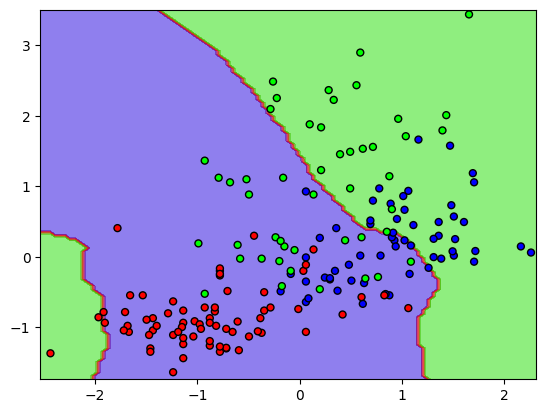

In [80]:
import numpy as np

def plot_boundary(X, y, model):
  x_min, x_max = X[:, 0].min()-0.1, X[:, 0].max()+0.1
  y_min, y_max = X[:, 1].min()-0.1, X[:, 1].max()+0.1

  spacing = min(x_max - x_min, y_max - y_min) / 100

  XX, YY = np.meshgrid(np.arange(x_min, x_max, spacing),
                       np.arange(y_min, y_max, spacing))

  data = np.hstack((XX.ravel().reshape(-1,1),
                    YY.ravel().reshape(-1,1)))

  # For binary problems
  # db_prob = model(Variable(torch.Tensor(data)).cuda() )
  # clf = np.where(db_prob.cpu().data < 0.5,0,1)

  # For multi-class problems
  db_prob = model(torch.Tensor(data).to(device) )
  clf = np.argmax(db_prob.cpu().data.numpy(), axis=-1)

  Z = clf.reshape(XX.shape)

  plt.contourf(XX, YY, Z, cmap=plt.cm.brg, alpha=0.5)
  plt.scatter(X[:,0], X[:,1], c=y, edgecolors='k', s=25, cmap=plt.cm.brg)


plot_boundary(data, targets, model)

In [81]:
from torch import optim

criterion = nn.CrossEntropyLoss().to(device)

optimizer = optim.SGD(model.parameters(), lr=1e-3)

In [82]:
X = torch.FloatTensor(data).to(device)
Y = torch.LongTensor(targets).to(device)

print(X.shape, Y.shape)

torch.Size([178, 2]) torch.Size([178])


In [83]:
for i in range(200):
  pred = model(X)
  loss = criterion(pred, Y)

  g = loss.backward()
  optimizer.step()

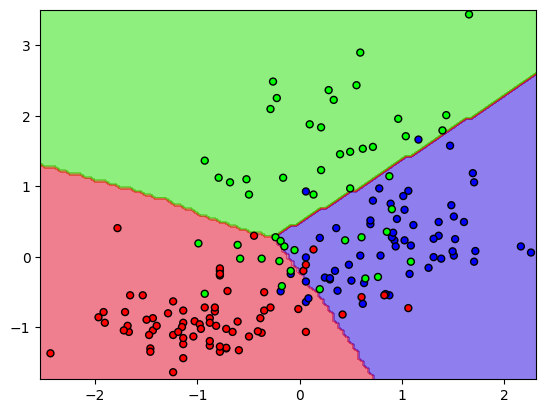

In [84]:
plot_boundary(data, targets, model)

RMSprop foi um otimizador que resolveu problemas de overfitting e funciona melhor que os outros.

Adam é outro que melhor se comporta nos problemas.

---
\
> Alguns hiperparâmetros dos otimizadores possuem valores padrão, que funcionam para a maioria dos problemas, como é o caso do momentum onde se sugere o valor 0.9. Já o decaimento de pesos (weight_decay) precisa ser ajustado para cada problema específico, e é um dos hiperparâmetros mais importantes do processo de otimização.

## Hiperparâmetros

In [85]:
args = {
    'batch_size': 20,
    'num_workers': 4,
    'weight_decay': 5e-4,
    'lr': 1e-4,
    'num_epochs': 30,
    'num_classes': 10

}

if torch.cuda.is_available():
  args['device'] = torch.device('cuda')
else:
  args['device'] = torch.device('cpu')

print(args['device'])

cpu


In [86]:
from torchvision import datasets, transforms

train_set = datasets.MNIST(root='./data', train=True,
                      transform = transforms.ToTensor(),
                      download=True)

test_set = datasets.MNIST(root='./data', train=False,
                      transform = transforms.ToTensor(),
                      download=False)

print("Amostras treino: " + str(len(train_set)))
print("Amostras teste: " + str(len(test_set)))

Amostras treino: 60000
Amostras teste: 10000


In [87]:
print(type(train_set))
print(train_set[0])

<class 'torchvision.datasets.mnist.MNIST'>
(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0

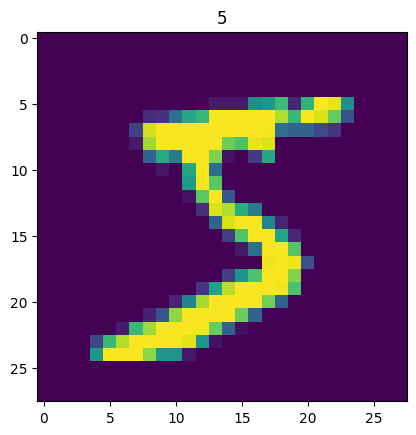

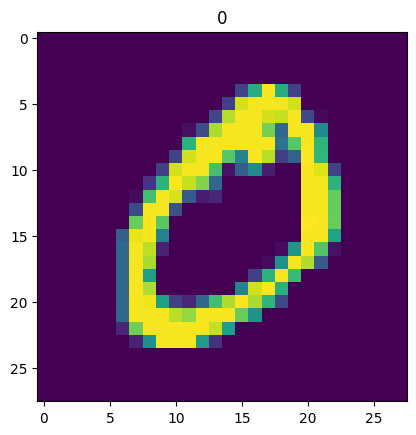

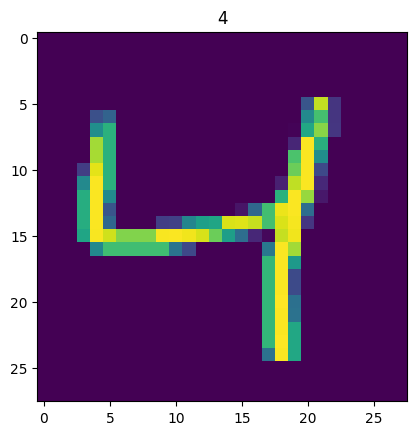

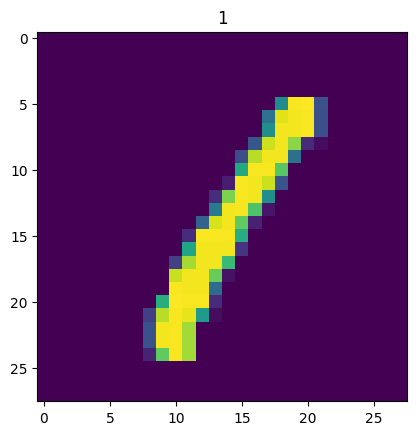

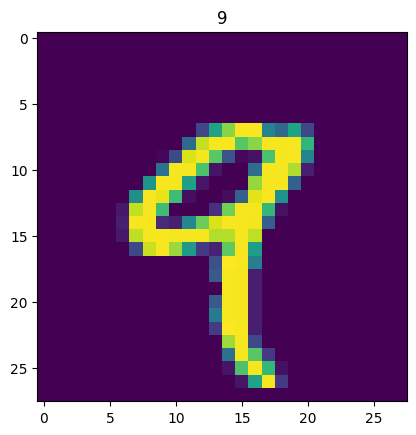

In [88]:
for i in range(5):
  dado, rotulo = train_set[i]

  plt.figure()
  plt.imshow(dado.squeeze())
  plt.title(str(rotulo))

## DataLoader

gerencia o carregamento de dados e treinamento.
Separa os batches, embaralha e carrega utilizando threads(o que minimiza períodos ociosos de processamento).

In [89]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_set, batch_size=args['batch_size'],
                          shuffle=True, num_workers=args['num_workers'])

test_loader = DataLoader(test_set, batch_size=args['batch_size'],
                         shuffle=True, num_workers=args['num_workers'])

/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


passando pelas imagens através de batches

torch.Size([20, 1, 28, 28]) torch.Size([20])


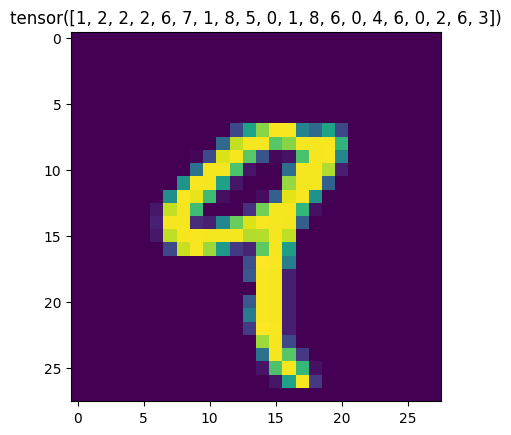

In [90]:
for batch in train_loader:
  dados, rotulo = batch
  print(dados.size(), rotulo.size())

  plt.imshow(dado.squeeze())
  plt.title(str(rotulo))
  break

## Fluxo de Treinamento

In [91]:
class MLP(nn.Module):
  def __init__(self, input_size, hidden_size, out_size):
    super(MLP, self).__init__()

    self.features = nn.Sequential(nn.Linear(input_size,hidden_size),
                                  nn.ReLU(),
                                  nn.Linear(hidden_size,hidden_size),
                                  nn.ReLU()
                                  )
    self.output = nn.Linear(hidden_size, out_size)
    #self.softmax = nn.Softmax()

  def forward(self, X):

    X = X.view(X.size(0), -1) #redimensiona o X linearizando, mas mantendo o tamanho das amostras
    feature = self.features(X)
    #output = self.softmax(self.output(feature))
    output = self.output(feature)

    return output

input_size = 28 * 28
hidden_size = 128
out_size = args['num_classes'] #num de classes

model = MLP(input_size, hidden_size, out_size).to(args['device'])

Exemplo de linearização do X:

> X.shape = (32, 1, 28, 28)  # batch de 32 imagens 1x28x28 (ex: MNIST)

1. Aplicando: X = X.view(X.size(0), -1)

Se torna:

> X = X.view(32, 784)  # pois 1 * 28 * 28 = 784

In [92]:
criterion = nn.CrossEntropyLoss().to(args['device'])

optimizer = optim.Adam(model.parameters(), lr=args['lr'],
                       weight_decay=args['weight_decay'])

nn.CrossEntropyLoss já aplica LogSoftmax internamente

In [93]:
for epoch in range(args['num_epochs']):

  epoch_loss = []

  for batch in train_loader:
    dados, rotulo = batch

    dados = dados.to(args['device'])
    rotulo = rotulo.to(args['device'])

    pred = model(dados)
    loss = criterion(pred, rotulo)
    epoch_loss.append(loss.cpu().data)

    loss.backward()
    optimizer.step()

epoch_loss = np.asarray(epoch_loss)

print('Época %d, Loss %.4f +/- %.4f' % (epoch, epoch_loss.mean(), epoch_loss.std()))

Época 29, Loss 0.6740 +/- 2.1161


In [94]:
from sklearn.metrics import accuracy_score, f1_score

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for data, labels in test_loader:
        outputs = model(data)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

In [95]:
acc = accuracy_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds, average='weighted')

print(f'Acurácia: {acc:.4f}')
print(f'F1 Score: {f1:.4f}')

Acurácia: 0.7809
F1 Score: 0.8195


/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


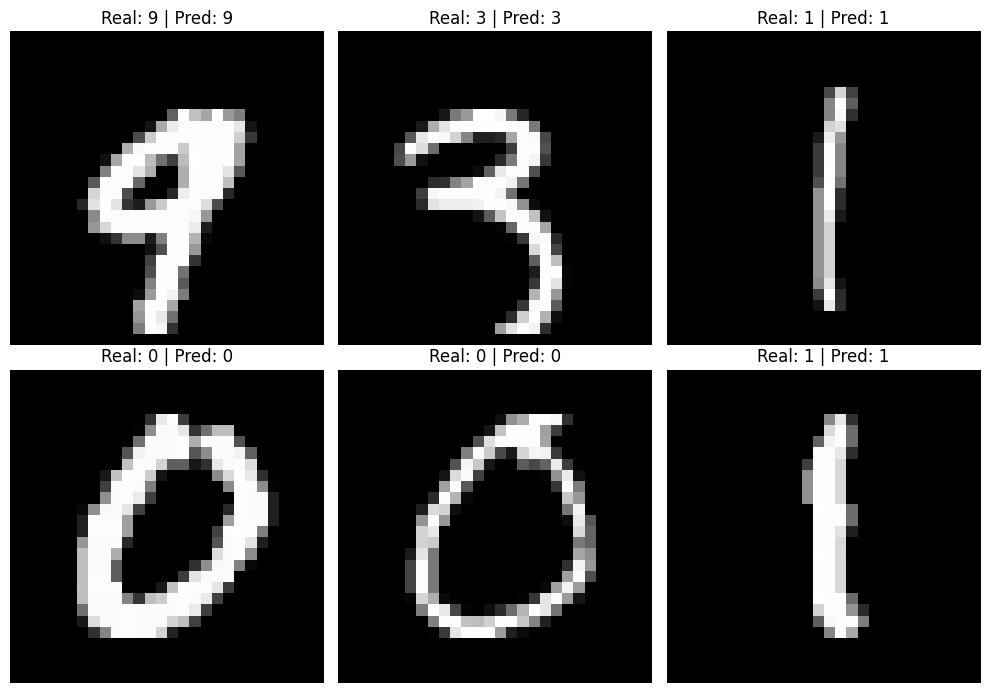

In [96]:
data_iter = iter(test_loader)
images, labels = next(data_iter)

model.eval()

with torch.no_grad():
    outputs = model(images)
    _, preds = torch.max(outputs, 1)

fig, axes = plt.subplots(2, 3, figsize=(10, 7))
axes = axes.flatten()

for i in range(6):
    img = images[i].squeeze().cpu().numpy()
    true_label = labels[i].item()
    pred_label = preds[i].item()

    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f"Real: {true_label} | Pred: {pred_label}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

### Datasets de aluguéis de bicicletas

In [97]:
from torch.utils.data import Dataset

In [98]:
!wget https://archive.ics.uci.edu/ml/machine-learning-databases/00275/Bike-Sharing-Dataset.zip
!unzip Bike-Sharing-Dataset.zip

--2025-03-28 13:02:33--  https://archive.ics.uci.edu/ml/machine-learning-databases/00275/Bike-Sharing-Dataset.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘Bike-Sharing-Dataset.zip.1’

Bike-Sharing-Datase     [   <=>              ] 273.43K   528KB/s    in 0.5s    

2025-03-28 13:02:34 (528 KB/s) - ‘Bike-Sharing-Dataset.zip.1’ saved [279992]

Archive:  Bike-Sharing-Dataset.zip
replace Readme.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: Readme.txt              
replace day.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: day.csv                 
replace hour.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: hour.csv                


In [99]:
!ls

Bike-Sharing-Dataset.zip    bike_test_csv   data     hour.csv	 sample_data
Bike-Sharing-Dataset.zip.1  bike_train_csv  day.csv  Readme.txt


In [100]:
import pandas as pd

df = pd.read_csv('hour.csv')
print(len(df))
df.head()

17379


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [101]:
torch.manual_seed(44)
indices = torch.randperm(len(df)).tolist()

train_size = int(0.8 * len(df))
train_df = df.iloc[indices[:train_size]]
test_df = df.iloc[indices[train_size:]]

In [108]:
train_df.to_csv('bike_train.csv', index=False)
test_df.to_csv('bike_test.csv', index=False)

In [109]:
!ls

Bike-Sharing-Dataset.zip    bike_test.csv  bike_train.csv  data     hour.csv	sample_data
Bike-Sharing-Dataset.zip.1  bike_test_csv  bike_train_csv  day.csv  Readme.txt


In [114]:
class Bike(Dataset):
  def __init__(self, csv_path, scaler_feat=None, scaler_label=None):
    self.dados = pd.read_csv(csv_path).to_numpy()

  def __getitem__(self, idx):
    sample = self.dados[idx][2:14]
    label  = self.dados[idx][-1:]

    sample = torch.from_numpy(sample.astype(np.float32))
    label  = torch.from_numpy(label.astype(np.float32))

    return sample, label

  def __len__(self):
    return len(self.dados)

In [115]:
train_set = Bike('bike_train.csv')
test_set = Bike('bike_test.csv')

dados,rotulo = train_set[0]
print(dados, rotulo)

tensor([2.0000, 0.0000, 3.0000, 1.0000, 0.0000, 2.0000, 1.0000, 1.0000, 0.4200,
        0.4242, 1.0000, 0.1343]) tensor([19.])


In [116]:
train_loader = DataLoader(train_set, batch_size=args['batch_size'],
                          shuffle=True, num_workers=args['num_workers'])

test_loader = DataLoader(test_set, batch_size=args['batch_size'],
                         shuffle=True, num_workers=args['num_workers'])

/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [117]:
for batch in train_loader:
  dados, rotulo = batch
  print(dados.size(), rotulo.size())
  break

torch.Size([20, 12]) torch.Size([20, 1])


### Fluxo de Validação

In [118]:
len(train_set[0][0]) #os dados sem o rótulo

12

In [119]:
len(train_set[0][1])

1

In [120]:
class MLP(nn.Module):
  def __init__(self, input_size, hidden_size, out_size):
    super(MLP, self).__init__()

    self.features = nn.Sequential(nn.Linear(input_size,hidden_size),
                                  nn.ReLU(),
                                  nn.Linear(hidden_size,hidden_size),
                                  nn.ReLU()
                                  )
    self.output = nn.Linear(hidden_size, out_size)
    #self.softmax = nn.Softmax()

  def forward(self, X):

    feature = self.features(X)
    #output = self.softmax(self.output(feature))
    output = self.output(feature)

    return output

input_size = len(train_set[0][0])
hidden_size = 128
out_size = 1 #num de variáveis preditas

model = MLP(input_size, hidden_size, out_size).to(args['device'])

In [121]:
criterion = nn.L1Loss().to(args['device'])

optimizer = optim.Adam(model.parameters(), lr=args['lr'],
                       weight_decay=args['weight_decay'])

In [122]:
def train(train_loader, model, epoch):
    model.train()
    start = time.time()
    epoch_loss = []

    for batch in train_loader:
      dados, rotulo = batch

      dados = dados.to(args['device'])
      rotulo = rotulo.to(args['device'])

      #forward
      pred = model(dados)
      loss = criterion(pred, rotulo)
      epoch_loss.append(loss.cpu().data)

      #backpropagation
      loss.backward()
      optimizer.step()

    epoch_loss = np.asarray(epoch_loss)

    end = time.time()

    print('--------- Train ---------')
    print('Epoch %d, Loss: %.4f +/- %.4f, Time: %.2f' % (epoch, epoch_loss.mean(), epoch_loss.std(), end-start))

    return epoch_loss.mean()

In [123]:
def validate(test_loader, model, epoch):
    model.eval()
    start = time.time()
    with torch.no_grad():
      epoch_loss = []

      for batch in train_loader:
        dados, rotulo = batch

        dados = dados.to(args['device'])
        rotulo = rotulo.to(args['device'])

        #forward
        pred = model(dados)
        loss = criterion(pred, rotulo)
        epoch_loss.append(loss.cpu().data)

      epoch_loss = np.asarray(epoch_loss)
      end = time.time()

      print('--------- Validate ---------')
      print('Epoch %d, Loss: %.4f +/- %.4f, Time: %.2f\n' % (epoch, epoch_loss.mean(), epoch_loss.std(), end-start))

      return epoch_loss.mean()


In [124]:
train_losses, test_losses = [], []

for epoch in range(args['num_epochs']):
   # Train
  train_losses.append(train(train_loader, model, epoch))
  # Validate
  test_losses.append(validate(test_loader, model, epoch))

--------- Train ---------
Epoch 0, Loss: 148.2281 +/- 39.8802, Time: 3.29
--------- Validate ---------
Epoch 0, Loss: 123.1816 +/- 24.4472, Time: 1.83

--------- Train ---------
Epoch 1, Loss: 122.1532 +/- 29.6042, Time: 3.47
--------- Validate ---------
Epoch 1, Loss: 117.2374 +/- 24.3848, Time: 2.47

--------- Train ---------
Epoch 2, Loss: 120.8982 +/- 28.5606, Time: 3.38
--------- Validate ---------
Epoch 2, Loss: 123.9706 +/- 31.7204, Time: 1.90

--------- Train ---------
Epoch 3, Loss: 117.3128 +/- 27.4690, Time: 3.48
--------- Validate ---------
Epoch 3, Loss: 114.1934 +/- 30.0389, Time: 2.89

--------- Train ---------
Epoch 4, Loss: 115.0804 +/- 28.9699, Time: 3.39
--------- Validate ---------
Epoch 4, Loss: 111.7935 +/- 24.6089, Time: 1.97

--------- Train ---------
Epoch 5, Loss: 107.6085 +/- 26.2588, Time: 3.47
--------- Validate ---------
Epoch 5, Loss: 107.3281 +/- 23.3293, Time: 2.36

--------- Train ---------
Epoch 6, Loss: 102.4411 +/- 26.2475, Time: 4.17
--------- Vali

In [126]:
Xtest = torch.stack([tup[0] for tup in test_set])
Xtest = Xtest.to(args['device'])

ytest = torch.stack([tup[1] for tup in test_set])
ypred = model(Xtest).cpu().data

data = torch.cat((ytest, ypred), axis=1)

df_results = pd.DataFrame(data, columns=['ypred', 'ytest'])
df_results.head(20)

,ypred,ytest
0,200.0,254.442154
1,18.0,32.313892
2,323.0,420.057037
3,372.0,106.642868
4,306.0,305.120789
5,121.0,321.299286
6,35.0,65.384972
7,69.0,152.603439
8,217.0,287.409882
9,130.0,106.141670


 ### gráfico de convergência

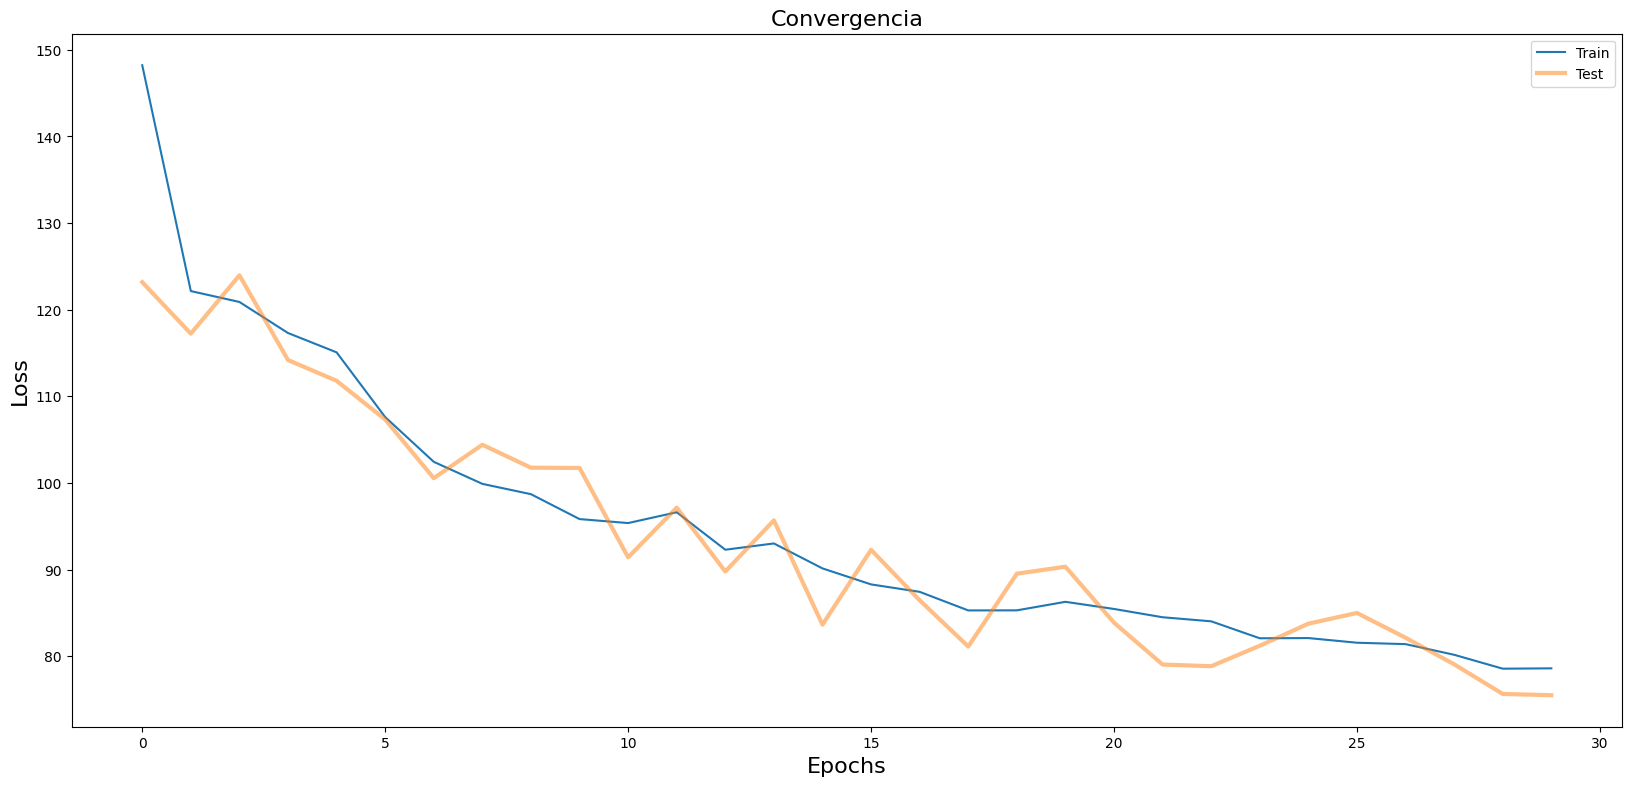

In [127]:
plt.figure(figsize=(20, 9))
plt.plot(train_losses, label='Train')
plt.plot(test_losses, label='Test', linewidth=3, alpha=0.5)
plt.xlabel('Epochs', fontsize=16)
plt.ylabel('Loss', fontsize=16)
plt.title('Convergencia', fontsize=16)
plt.legend()
plt.show()

## Passos importantes

* Papel da função de perda no aprendizado.
* Funções de perda para regressão.
* Funções de perda para classificação.
* Convergência de modelos.
* Papel da função de perda no cálculo do gradiente
* Descida do Gradiente
* Definindo uma taxa de aprendizado
* Otimização de problemas com PyTorch.
* Padronização dos dados.
* Papel dos hiperparâmetros no treinamento.
* Otimizadores mais usados.
* Hiperparâmetros de treinamento: Batch, Iteração e Época.
* Carregamento de dados com Torchvision.
* DataLoader no PyTorch.
* Fluxo completo de treinamento.
* Carregamento de dados customizado.
* Dataset no PyTorch.
* Fluxo completo de validação.